# Streaming messages
- .stream, .astream, .astream_events
- Three important stream modes - "values", "updates", "messages"

### Boilerplate code - llm initiation

In [8]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama
import os
from dotenv import load_dotenv

load_dotenv("./env")

google_api_key = os.getenv("GOOGLE_API_KEY")
openai_api_key = os.getenv("OPENAI_API_KEY")

google_llm = ChatGoogleGenerativeAI(
    temperature=0, 
    model="gemini-2.5-flash", 
    api_key=google_api_key,
    max_tokens=200
)

openai_llm = ChatOpenAI(
    temperature=0, 
    model="gpt-4", 
    api_key=openai_api_key
)

ollama_llm = ChatOllama(
    model="llama3.1:latest",
    temperature=0
)

# google_llm.invoke("Hello")

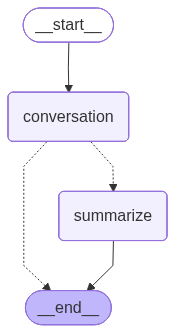

In [9]:
from langgraph.graph import StateGraph, START, END, MessagesState
from IPython.display import display, Image
from typing import Literal, Optional
from langchain_core.messages import HumanMessage, AIMessage, RemoveMessage, SystemMessage
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

MESSAGE_LENGTH = 4


class MessagesState(MessagesState):
    summary: Optional[str] = None

def conversation(state: MessagesState):
    summary = state.get('summary')
    if summary:
        messages_for_invoke = [SystemMessage(content=f"Here is the summary of the conversation to date: {summary}")] + state.get('messages')
    else:
        messages_for_invoke = state.get('messages')
    
    return {"messages": google_llm.invoke(messages_for_invoke)}

def summarize(state: MessagesState):
    print("Summarizing...")

    summary = state.get('summary')
    if summary:
        summary_message = (
            f"Here is the summary of the conversation to date: {summary}.\n\n"
            "Extend this summary with the new messages above:"
        )
    else:
        summary_message = f"Summarize this conversation: "

    messages = state.get('messages') + [HumanMessage(content=summary_message)]
    res = google_llm.invoke(messages)
    
    delete_messages = [RemoveMessage(msg.id) for msg in state['messages'][:-2]]
    
    # print(f"After summary: \n {res.content} \n Delete messages: \n{delete_messages}")

    return {"summary": res.content, "messages": delete_messages}

def should_summarize(state: MessagesState) -> Literal['__end__', "summarize"]:
    messages =  state['messages']
    print("Checking should summarize...")
    print(f"Messages length: {len(messages)}")
    if len(messages) <= MESSAGE_LENGTH:
        print("Not summarizing...")
        return END
    else:
        return "summarize"

builder = StateGraph(MessagesState)

builder.add_node("conversation", conversation)
builder.add_node("summarize", summarize)

builder.add_edge(START, "conversation")
builder.add_conditional_edges("conversation", should_summarize)
builder.add_edge("summarize", END)


graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

##### .invoke outputs list of messages after all node run

In [ ]:
config = {"configurable": {"thread_id": "jjj"}}

res = graph.invoke({"messages": HumanMessage(content="Hi, I am Praveen.")}, config=config)

print(f"Res is {res}")

for msg in res.get('messages'):
    msg.pretty_print()

print(f"\n\nSummary is \n{res.get('summary')}")

##### .stream produces state output of each node in real time

In [ ]:
config = {"configurable": {"thread_id": "jjj"}}

chunks = graph.stream({"messages": HumanMessage(content="I work in Software.")}, config=config, stream_mode="updates")

for chunk in chunks:
    print(chunk)

In [ ]:
config = {"configurable": {"thread_id": "jjj"}}

chunks = graph.stream({"messages": HumanMessage(content="I like Computers.")}, config=config, stream_mode="values")

for chunk in chunks:
    print(chunk)

In [ ]:
for key, value in memory.storage.items():
    print("Key ", key)
    print("Value ", value)

In [ ]:
current_state = graph.get_state(config).values

messages = current_state.get('messages')

# print(current_state.get('messages'))

for m in messages:
    print(m)

### .astream_events
- To get low level streaming like (on_chat_model_stream, on_tool_start, on_node_end)
- get each token as the LLM generates it

In [ ]:
node_to_stream = 'summarize'

config = {"configurable": {"thread_id": "5"}}
input_message = HumanMessage(content="Tell me about the CSK cricket team in 2 lines")
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    # Get chat model tokens from a particular node
    if event["event"] == "on_chat_model_stream" and event['metadata'].get('langgraph_node','') == node_to_stream:
        data = event["data"]
        print(data["chunk"].content, end="")

### Stream experiments

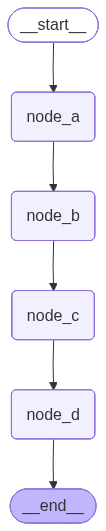

In [ ]:
from langgraph.graph import StateGraph, START, END, MessagesState
from IPython.display import display, Image
import time


def node_a(state:MessagesState) -> MessagesState:
    print("Adding A", "\n")
    time.sleep(1)
    return {'messages': "I am A"}

def node_b(state:MessagesState) -> MessagesState:
    print("Adding B", "\n")
    time.sleep(1)
    return {'messages': "I am B"}

def node_c(state:MessagesState) -> MessagesState:
    print("Adding C", "\n")
    time.sleep(1)
    return {'messages': "I am C"}

def node_d(state:MessagesState) -> MessagesState:
    print("Adding D", "\n")
    time.sleep(1)
    return {'messages': "I am D"}



builder = StateGraph(MessagesState)

builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)
builder.add_node("node_d", node_d)


builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", "node_c")
builder.add_edge("node_c", "node_d")
builder.add_edge("node_d", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


##### .invoke -> returns only once, will get list of messages as output

In [11]:
res = graph.invoke({"messages": "I am Praveen"})
messages = res.get('messages')

messages

# for msg in messages:
#     print(msg)

Adding A 

Adding B 

Adding C 

Adding D 



[HumanMessage(content='I am Praveen', additional_kwargs={}, response_metadata={}, id='7f9756a3-9ea4-4858-a505-c9377625f1e2'),
 HumanMessage(content='I am A', additional_kwargs={}, response_metadata={}, id='21c5f726-ecff-4edc-9946-9e77ab5f7b8a'),
 HumanMessage(content='I am B', additional_kwargs={}, response_metadata={}, id='a15898ba-1ded-4617-9e30-fffd2a777a1d'),
 HumanMessage(content='I am C', additional_kwargs={}, response_metadata={}, id='b63afc2b-cd2f-423b-b28d-be68f1409a1e'),
 HumanMessage(content='I am D', additional_kwargs={}, response_metadata={}, id='ce07e0d3-a70e-4b1e-a5d6-2c64a6c04902')]

##### .stream, stream_mode='values' -> Will stream State output after each node (with "messages" key in our case)

In [12]:
config = {"config": {"configurable": {"thread_id": 2}}}

chunks = graph.stream({"messages": "I am Praveen"}, config=config, stream_mode="values")

for chunk in chunks:
    print(chunk, "\n")

# # To get just the final node output only (simply use .invoke instead)
# for chunk in chunks:
#     pass
# print(chunk.get('messages')[-1])


{'messages': [HumanMessage(content='I am Praveen', additional_kwargs={}, response_metadata={}, id='61fcf2ca-5a67-4a10-91fb-cad2e591be31')]} 

Adding A 

{'messages': [HumanMessage(content='I am Praveen', additional_kwargs={}, response_metadata={}, id='61fcf2ca-5a67-4a10-91fb-cad2e591be31'), HumanMessage(content='I am A', additional_kwargs={}, response_metadata={}, id='b912fba5-f0ca-4b64-b267-feaad4f8c821')]} 

Adding B 

{'messages': [HumanMessage(content='I am Praveen', additional_kwargs={}, response_metadata={}, id='61fcf2ca-5a67-4a10-91fb-cad2e591be31'), HumanMessage(content='I am A', additional_kwargs={}, response_metadata={}, id='b912fba5-f0ca-4b64-b267-feaad4f8c821'), HumanMessage(content='I am B', additional_kwargs={}, response_metadata={}, id='b4f57a3e-5f06-4abe-9750-5c447193296f')]} 

Adding C 

{'messages': [HumanMessage(content='I am Praveen', additional_kwargs={}, response_metadata={}, id='61fcf2ca-5a67-4a10-91fb-cad2e591be31'), HumanMessage(content='I am A', additional_kwa

##### .stream, stream_mode='updates' -> Will stream just node return output(not state) for each node

In [18]:
config = {"config": {"configurable": {"thread_id": 11}}}

chunks = graph.stream({"messages": "I am Praveen"}, config=config, stream_mode="updates")
for chunk in chunks:
    print(chunk,  "\n")
    # if chunk.get('node_b'):
    #     print("Printing conditionally...")
    #     print(chunk.get('node_b'), "\n")

Adding A 

{'node_a': {'messages': 'I am A'}} 

Adding B 

{'node_b': {'messages': 'I am B'}} 

Adding C 

{'node_c': {'messages': 'I am C'}} 

Adding D 

{'node_d': {'messages': 'I am D'}} 



##### .stream, stream_mode='messages' -> Only streams output from LLM calls (ChatModel invocations

In [19]:
config = {"config": {"configurable": {"thread_id": "abc"}}}

chunks = graph.stream({"messages": "I am Praveen"}, config=config, stream_mode="messages")
for chunk in chunks:
    print(chunk,  "\n")

Adding A 

Adding B 

Adding C 

Adding D 



## LLM Graph for stream_mode='messages' demo

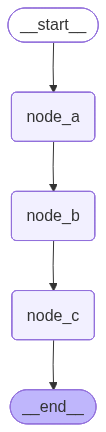

In [24]:
from langgraph.graph import StateGraph, START, END, MessagesState
from IPython.display import display, Image
from langchain_core.messages import SystemMessage, HumanMessage


def node_a(state:MessagesState) -> MessagesState:
    print("Adding A", "\n")
    last_msg = state["messages"][-1].content
    google_llm.invoke("What is 2+2? Just give the answer")
    return {'messages': google_llm.invoke
    ([SystemMessage(content="Take the following text and append the letter 'A' to the end. Return ONLY the modified text."), HumanMessage(content=last_msg)])}

def node_b(state:MessagesState) -> MessagesState:
    print("Adding B", "\n")
    last_msg = state["messages"][-1].content
    return {'messages': google_llm.invoke
    ([SystemMessage(content="Take the following text and append the letter 'B' to the end. Return ONLY the modified text."), HumanMessage(content=last_msg)])}

def node_c(state:MessagesState) -> MessagesState:
    print("Adding C", "\n")
    last_msg = state["messages"][-1].content
    return {'messages': google_llm.invoke
    ([SystemMessage(content="Take the following text and append the letter 'C' to the end. Return ONLY the modified text."), HumanMessage(content=last_msg)])}


builder = StateGraph(MessagesState)

builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)


builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", "node_c")
builder.add_edge("node_c", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


#### stream_mode='messages' -> Outputs AIMessageChunk and extra AIMessageChunk and chunk_position='last' to make the end of stream

In [25]:
config = {"config": {"configurable": {"thread_id": "jfjfjfj"}}}

chunks = graph.stream({"messages": "I am Praveen"}, config=config, stream_mode="messages")
for chunk in chunks:
    print(chunk,  "\n")

Adding A 

(AIMessageChunk(content='4', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d539e-1cea-7181-b10e-0a0f9a8effca', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 36, 'total_tokens': 48, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 35}}, tool_call_chunks=[]), {'langgraph_step': 1, 'langgraph_node': 'node_a', 'langgraph_triggers': ('branch:to:node_a',), 'langgraph_path': ('__pregel_pull', 'node_a'), 'langgraph_checkpoint_ns': 'node_a:00547687-f172-f29b-8a88-a5fc5fce98e4', 'model': 'gemini-2.5-flash', 'temperature': 0.0, 'max_output_tokens': 200, 'n': 1, '_type': 'chat-google-generative-ai', 'checkpoint_ns': 'node_a:00547687-f172-f29b-8a88-a5fc5fce98e4', 'ls_provider': 'google_genai', 'ls_model_name': 'gemini-2.5-flash', 'ls_model_type': 'chat', 'ls_temperature': 0.0, 'ls_max_toke

##### stream_mode=["values", "messages"] -> Can combine stream modes, outputs a tuple in this format when combined (mode_name, data)

In [26]:
config = {"config": {"configurable": {"thread_id": "nvbnvjvjm"}}}

chunks = graph.stream({"messages": "I am Praveen"}, config=config, stream_mode=["values", "messages"])
for chunk in chunks:
    print(chunk,  "\n")

('values', {'messages': [HumanMessage(content='I am Praveen', additional_kwargs={}, response_metadata={}, id='d7680623-d73c-4b2e-b00b-1cd1e1f598da')]}) 

Adding A 

('messages', (AIMessageChunk(content='4', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d539e-9385-78d0-a5ae-e22241ab57b8', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 52, 'total_tokens': 64, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 51}}, tool_call_chunks=[]), {'langgraph_step': 1, 'langgraph_node': 'node_a', 'langgraph_triggers': ('branch:to:node_a',), 'langgraph_path': ('__pregel_pull', 'node_a'), 'langgraph_checkpoint_ns': 'node_a:f32b28c7-5b43-1787-54dd-4a7c27169509', 'model': 'gemini-2.5-flash', 'temperature': 0.0, 'max_output_tokens': 200, 'n': 1, '_type': 'chat-google-generative-ai', 'checkpoint_ns': 'node_a: